/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


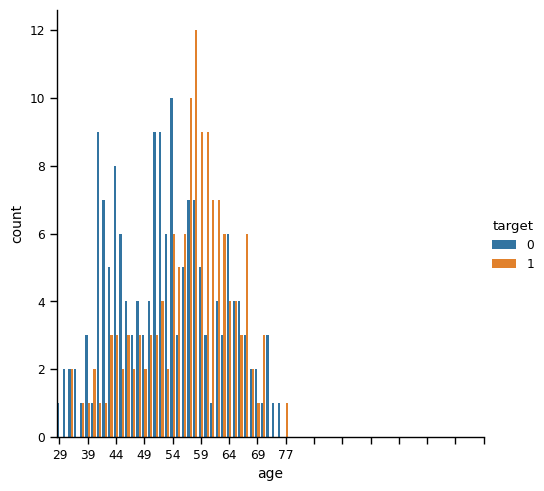

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Bài tập 1
df = pd.read_csv('/kaggle/input/module3/cleveland.csv', header = None)
df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol',
              'fbs', 'restecg', 'thalach', 'exang',
              'oldpeak', 'slope', 'ca', 'thal', 'target']
df['target'] = df.target.map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})
df['thal'] = df.thal.fillna(df.thal.mean())
df['ca'] = df.ca.fillna(df.ca.mean())

# distribution of target vs age

#.         Your code here ******************

sns.set_context("paper", font_scale = 1, rc ={
    "font_size":3, 
    "axes.titlesize":15,
    "axes.labelsize":10
})

ax = sns.catplot(kind = 'count', data=df, x='age', hue='target', order=df['age'].sort_values().unique())
ax.ax.set_xticks(np.arange(0,80,5))

plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


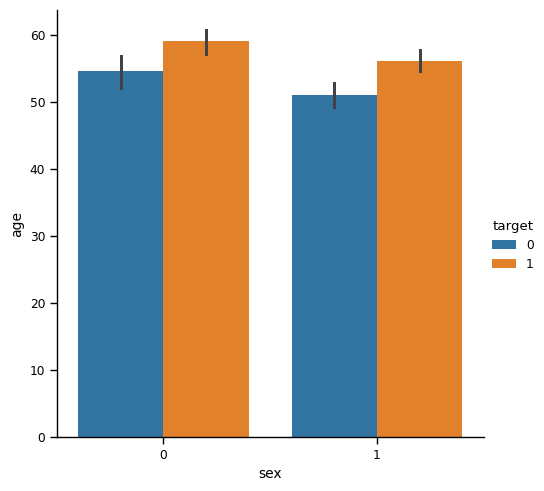

In [2]:
sns.catplot(kind = 'bar',data=df,y='age',x='sex',hue='target')
plt.show()

In [3]:
!pip install scikit-learn


X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred)  # Correct order: y_test, y_pred

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)  # Correct order: y_train, y_pred_train

accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

print()
print(f'Accuracy for training set for KNeighborsClassifier = {accuracy_for_train}')
print(f'Accuracy for test set for KNeighborsClassifier = {accuracy_for_test}')



Accuracy for training set for KNeighborsClassifier = 0.76
Accuracy for test set for KNeighborsClassifier = 0.69


In [4]:
#########################################   SVM   #############################################################

#Bai Tap 4

#.         Your code here ******************
from sklearn.svm import SVC
classifier= SVC(kernel = 'rbf',random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred)  # Correct order: y_test, y_pred

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)  # Correct order: y_train, y_pred_train


print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for SVC = {}'.format(accuracy_for_train))
print('Accuracy for test set for SVC = {}'.format(accuracy_for_test))



Accuracy for training set for SVC = 0.66
Accuracy for test set for SVC = 0.67


In [5]:
#########################################   Naive Bayes  #############################################################
# Bai tap 5

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************
from sklearn.naive_bayes import GaussianNB
classifier= GaussianNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred)  # Correct order: y_test, y_pred

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)  # Correct order: y_train, y_pred_train

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for GaussianNB = {}'.format(accuracy_for_train))
print('Accuracy for test set for GaussianNB = {}'.format(accuracy_for_test))



Accuracy for training set for GaussianNB = 0.85
Accuracy for test set for GaussianNB = 0.84


In [6]:
#Bai tap 6

#########################################   Decision Tree  #############################################################
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=10, 
    min_samples_split=2
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred)  # Correct order: y_test, y_pred

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)  # Correct order: y_train, y_pred_train


print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for DecisionTreeClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for DecisionTreeClassifier = {}'.format(accuracy_for_test))



Accuracy for training set for DecisionTreeClassifier = 1.0
Accuracy for test set for DecisionTreeClassifier = 0.74


In [7]:
#########################################  Random Forest  #############################################################
#bai tap 7
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(
    criterion='gini', 
    max_depth=10, 
    min_samples_split=2,
    n_estimators = 10, 
    random_state=42
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred)  # Correct order: y_test, y_pred

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)  # Correct order: y_train, y_pred_train



print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for RandomForestClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for RandomForestClassifier = {}'.format(accuracy_for_test))


Accuracy for training set for RandomForestClassifier = 0.98
Accuracy for test set for RandomForestClassifier = 0.8


In [8]:
# bap tap 8
###############################################################################
# applying Adaboost


X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************
from sklearn.ensemble import AdaBoostClassifier
classifier = AdaBoostClassifier(
    n_estimators=50, 
    learning_rate=1.0
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred)  # Correct order: y_test, y_pred

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)  # Correct order: y_train, y_pred_train


print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for AdaBoostClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for AdaBoostClassifier = {}'.format(accuracy_for_test))


Accuracy for training set for AdaBoostClassifier = 0.91
Accuracy for test set for AdaBoostClassifier = 0.84


In [9]:
# Bai tap 9
###############################################################################
# Gradient Adaboost

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************
from sklearn.ensemble import GradientBoostingClassifier
classifier = GradientBoostingClassifier(
    learning_rate=0.1, 
    n_estimators=100, 
    subsample=1.0, 
    min_samples_split=2, 
    max_depth=3,
    random_state=42
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred)  # Correct order: y_test, y_pred

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)  # Correct order: y_train, y_pred_train



print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for GradientBoostingClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for GradientBoostingClassifier = {}'.format(accuracy_for_test))



Accuracy for training set for GradientBoostingClassifier = 1.0
Accuracy for test set for GradientBoostingClassifier = 0.85


In [10]:
!pip install xgboost
import xgboost as xgb
from xgboost import XGBClassifier
classifier = XGBClassifier(objective="binary:logistic", random_state=42, n_estimators = 100)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm_test = confusion_matrix(y_test, y_pred)  # Correct order: y_test, y_pred

y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)  # Correct order: y_train, y_pred_train
print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for XGBClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for XGBClassifier = {}'.format(accuracy_for_test))



Accuracy for training set for XGBClassifier = 1.0
Accuracy for test set for XGBClassifier = 0.87


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Tạo X và y từ dataframe df
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Chia dữ liệu thành train và test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo các mô hình học máy
dtc = DecisionTreeClassifier(random_state=42)
rfc = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
xgb = XGBClassifier()
gc = GradientBoostingClassifier(random_state=42)
svc = SVC(kernel='rbf', random_state=42)
ad = AdaBoostClassifier(random_state=42)

# Tạo mô hình stacking
estimators = [
    ('dtc', dtc),
    ('rfc', rfc),
    ('knn', knn),
    ('gc', gc),
    ('ad',ad),
    ('svc', svc),
]
xg=XGBClassifier()

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=xg
)

# Huấn luyện mô hình stacking
stacking_model.fit(X_train, y_train)

# Dự đoán trên tập huấn luyện và tập kiểm tra
y_pred_train = stacking_model.predict(X_train)
y_pred_test = stacking_model.predict(X_test)

# Tính toán ma trận nhầm lẫn
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)

# Tính toán độ chính xác
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả
print(f'Accuracy for training set for Stacking = {accuracy_for_train}')
print(f'Accuracy for test set for Stacking = {accuracy_for_test}')


Accuracy for training set for Stacking = 0.92
Accuracy for test set for Stacking = 0.89
